# Workflow for groundcover and complexity estimation
To start, activate the right conda environment and move the active directory to the right place.

In [ ]:
conda activate rra_plot_3.11

cd NAS/Paper_1/NeuralNetworks/rra_plots_KH

When wanting to train all models, run **1_train_all_models.sh**. Predicting with all latest models run **2_run_predictions.sh**. Afterwards, the script post_train_predict_script.py. This does a number of things:
- Plotting of history file (MSE during training)
- Transform history file into a .csv file
- Transform validation file into a .csv file
To run the post prediction script for all the latest models use: **3_post_train.sh**

## I. Training AI instance for groundcover

The file <train_val.py> is used to train a instance. It uses different model, the models that can be used are visible in the <model_zoo.py>

currently (05.04.2024) available models are:
- "B0": keras.applications.EfficientNetB0
- "B2": keras.applications.EfficientNetB2
- "B4": keras.applications.EfficientNetB4
- "B5": keras.applications.EfficientNetB5
- "B7": keras.applications.EfficientNetB7   (has some issues/does not run properly)
- "XCEPTION": keras.applications.Xception
- "CNT" : keras.applications.ConvNeXtTiny
- "CNS" : keras.applications.ConvNeXtSmall
- "CNB" : keras.applications.ConvNeXtBase
- "CNL" : keras.applications.ConvNeXtLarge
- "CNXL": keras.applications.ConvNeXtXLarge

In [ ]:
python train_val.py -m <model_handle> --csv OG_data/paths_and_labels.csv -o output/groundcover/ -gc TRUE

### I.I Creating a graph to visualize the training process
During the training process the predictions of the AI get all the more better. This is also evaluated during the run.
The data of the training and evaluation process is stored in the model path in a history file.

The script <plot_metrics.py> can be used to vialize the results of training and evaluation.

In [ ]:
python plot_metrics  output/groundcover/<model_name>/<date-time_ofrun>/history

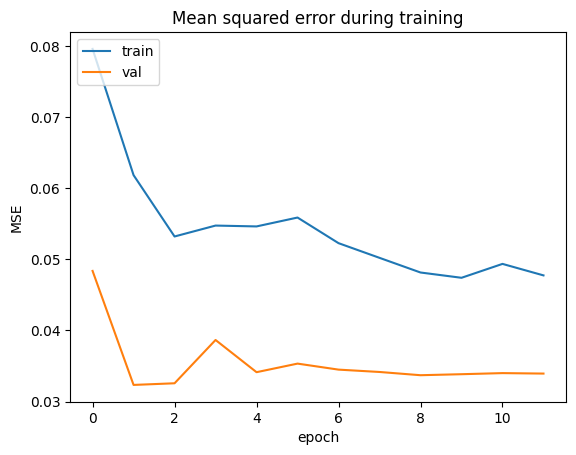

In [36]:
import pickle
from sys import argv
import matplotlib.pyplot as plt
from pathlib import Path

histfile = Path('E:/NeuralNetworks/rra_plots_KH/output/groundcover/convnext_xlarge/0109-134759/history') # Enter path here

with open(histfile, 'rb') as src:
    history = pickle.load(src)

plt.plot(history['mean_squared_error'])
plt.plot(history['val_mean_squared_error'])

plt.title('Mean squared error during training')
plt.ylabel('MSE')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.savefig(histfile.parent.joinpath('training_metrics.png'))
plt.show()

## II. Training AI instance for complexity
The file <train_val.py> is used to train a instance. It uses different model, the models that can be used are visible in the <model_zoo.py>

currently (05.04.2024) available models are:
- "B0": keras.applications.EfficientNetB0
- "B2": keras.applications.EfficientNetB2
- "B4": keras.applications.EfficientNetB4
- "B5": keras.applications.EfficientNetB5
- "B7": keras.applications.EfficientNetB7   (has some issues/does not run properly)
- "XCEPTION": keras.applications.Xception
- "CNT" : keras.applications.ConvNeXtTiny 
- "CNS" : keras.applications.ConvNeXtSmall
- "CNB" : keras.applications.ConvNeXtBase
- "CNL" : keras.applications.ConvNeXtLarge
- "CNXL": keras.applications.ConvNeXtXLarge

In [ ]:
python train_val.py -m <model_handle> --csv OG_data/compl_clean_nolink.csv -o output/complexity/

### II.I Visualize training process
Next once again the training and evaluation can be visualized as above.

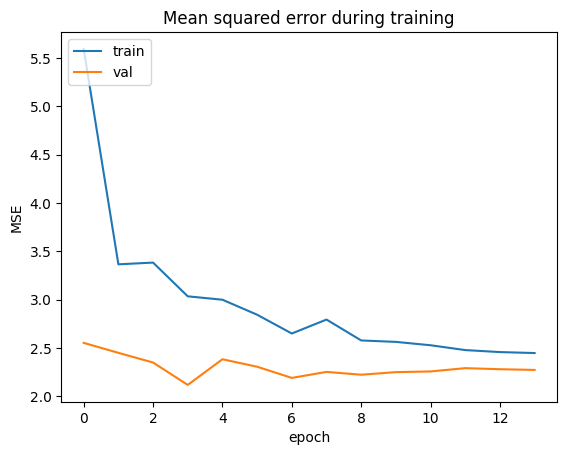

In [16]:
import pickle
from sys import argv
import matplotlib.pyplot as plt
from pathlib import Path

histfile = Path('E:/NeuralNetworks/rra_plots_KH/output/complexity/convnext_xlarge/0108-131416/history') # Enter path here

with open(histfile, 'rb') as src:
    history = pickle.load(src)

plt.plot(history['mean_squared_error'])
plt.plot(history['val_mean_squared_error'])

plt.title('Mean squared error during training')
plt.ylabel('MSE')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.savefig(histfile.parent.joinpath('training_metrics.png'))
plt.show()

## III. Predicting the values in all pictures
Now that the model is trained and the resulting training and evaluation is looking good, the model can be used to predict the values of other pictures.

Here the <predict.py> file is used.

A "predictions.csv" file is the result of this run.

When running for complexity (not groundcover) the -gc parameter is not used.

In [ ]:
python predict.py -m <model_handle> -o output/<groundcover/complexity>/<model_name>/<date-time_ofRun> -gc TRUE

## IV. Combining ground truth and prediction

### IV.I Ground cover
Ground truth as safed in OG_data/paths_and_labels.csv or OG_data/compl_clean_nolink.csv and the predictions safed in each model output file.

In [49]:
import pandas as pd

df = pd.read_csv('output/groundcover/xception/0109-130134/predictions.csv') # change code to the prefered file
gc_gt = pd.read_csv('OG_data/paths_and_labels.csv')

merged = df.merge(gc_gt, on='image_path', suffixes=('_pr','_gt'))

names = [n for n in merged.columns if n.startswith('gc')]

for name in names:
    base = name[:-2]
    feature = name.split('_')[1]
    merged[f'{feature}_delta'] = round(abs(merged[f'{base}pr'] - merged[f'{base}gt']))

merged.to_csv('gc_XC_sel.csv', index=False)

The 1242 files for ground cover can be further aggregated on a "Plot" level.

In [50]:
import pandas as pd
#from sys import argv

#_, csv_file, output = argv
csv_file = "E:/NeuralNetworks/rra_plots_KH/gc_XC_sel.csv" # path to the .csv file that is to be aggregated
output = "gc_XC_aggr" # path/name of the file that is created

df = pd.read_csv(csv_file)

df['image_path'] = df['image_path'].apply(lambda x: '_'.join(x.split('/')[-1].split('_')[:3]))
df = df.groupby('image_path').mean()

df = df.reset_index().rename(columns={'image_path': 'patch'})
df.to_csv(f'{output}.csv', index=False)

### IV.II Complexity
Complexity ground truth is safed in "OG_data/compl_clean_nolink.csv" and the predictions in each models output file.

In [28]:
import pandas as pd

df = pd.read_csv('output/complexity/xception/0429-112912/predictions.csv') # change path to the prefered file
co_gt = pd.read_csv('OG_data/compl_clean_nolink.csv')

merged = df.merge(co_gt, on='image_path', suffixes=('_pr','_gt'))

names = [n for n in merged.columns if n.startswith('grade')]

for name in names:
    base = name[:-2]
    feature = name.split('_')[1]
    merged[f'{feature}_delta'] = round(abs(merged[f'{base}pr'] - merged[f'{base}gt']))

merged.to_csv('co_B2_sel.csv', index=False)

In some cases it might be usefull to have the data aggregated for further analysis. So in the next step the data is aggregated.

In [7]:
import pandas as pd

csv_file = "E:/NeuralNetworks/rra_plots_KH/co_XCe_sel.csv" # Path to the .csv file that is to be aggregated
output = "co_XCe_aggr" # path/name of the file that is created

df = pd.read_csv(csv_file)

df['image_path'] = df['image_path'].apply(lambda x: '_'.join(x.split('/')[-1].split('_')[:3]))
df = df.groupby('image_path').mean()

df = df.reset_index().rename(columns={'image_path': 'patch'})
df.to_csv(f'{output}.csv', index=False)

# Accecibility of history file outside Python
Converting history file into a .csv file that is accessible outside Python.

In [1]:
import pickle
from pathlib import Path
import csv

#l_strPath = 'E:/NeuralNetworks/rra_plots_KH/output/groundcover/xception/0326-153032' # Enter path here
#l_strPath = './output/groundcover/xception/0326-153032' # Enter path here
l_strPath = './output/complexity/xception/0327-020842' # Enter path here
histfile = Path(f'{l_strPath}/history')

with open(histfile, 'rb') as src:
    history = pickle.load(src)

print(history)

# Flatten the dictionary
flat_history = {}
for key, value in history.items():
    flat_history[key] = value

# Determine the maximum length of lists to set the number of columns in CSV
max_length = max(len(lst) for lst in flat_history.values())

# Fill shorter lists with None values to make them all the same length
for key, value in flat_history.items():
    flat_history[key] = value + [None] * (max_length - len(value))

# Write to CSV
with open(Path(f'{l_strPath}/history.csv'), 'w', newline='') as f: # Enter path here as well
    w = csv.DictWriter(f, fieldnames=flat_history.keys())
    w.writeheader()
    for i in range(max_length):
        row = {key: flat_history[key][i] for key in flat_history}
        w.writerow(row)

{'loss': [0.44974130392074585, 0.4193388521671295, 0.3984158933162689, 0.3698076009750366, 0.3498697578907013, 0.32051172852516174, 0.30261263251304626, 0.2779287099838257, 0.25751742720603943, 0.2346322238445282, 0.2110138088464737, 0.2002173513174057, 0.17744505405426025, 0.16401106119155884, 0.14717447757720947, 0.13150891661643982, 0.12185760587453842, 0.11119027435779572, 0.10585937649011612, 0.09497465938329697, 0.09446242451667786, 0.08589731156826019, 0.07960157096385956, 0.07375011593103409, 0.07241694629192352, 0.06877033412456512, 0.06789135187864304, 0.06563146412372589, 0.061612796038389206, 0.059728410094976425, 0.0568661168217659, 0.05492352321743965, 0.05356074869632721, 0.049136172980070114, 0.049505382776260376, 0.049779463559389114, 0.04739873856306076, 0.04511168226599693, 0.042618926614522934, 0.041471801698207855, 0.041252993047237396, 0.0401698462665081, 0.03925362974405289, 0.0381220281124115, 0.03921257331967354, 0.03691992163658142, 0.03633501008152962, 0.0348

# Try to make val_ file accecible
The .npy file holds the information from the validation and test run, so in order to evaluate the test run. Goal is to have a look into this type of file.

In [2]:
import numpy as np
import pandas as pd
from pathlib import Path

l_strPath = Path('E:/NeuralNetworks/rra_plots_KH/output/complexity/xception/0108-105709/') # <----- HERE
l_npy_file = Path(f'{l_strPath}/tst_xception.npy') # <----- HERE

with open(l_npy_file, 'rb') as src:
    l_npy = np.lib.format.read_array(src)

l_df = pd.DataFrame(data=l_npy[0:,0:])
l_df = l_df.T

l_gc = False # <----- HERE
if (l_gc):
    # use this list of columns for groundcover
    # gc_Mature_Trees,gc_rejuvenation,gc_shrub_layer,gc_mosses,gc_ferns,gc_herb_layer,
    # gc_grasses,gc_soil/foliage,gc_rock,gc_deadwood/stumps
    l_strCols = "gc_Mature_Trees","gc_rejuvenation","gc_shrub_layer","gc_mosses","gc_ferns","gc_herb_layer","gc_grasses","gc_soil/foliage","gc_rock","gc_deadwood/stumps"
    l_strGTCols = "gc_Mature_Trees_gt","gc_rejuvenation_gt","gc_shrub_layer_gt","gc_mosses_gt","gc_ferns_gt","gc_herb_layer_gt","gc_grasses_gt","gc_soil/foliage_gt","gc_rock_gt","gc_deadwood/stumps_gt"
else:
    # use this list of columns for complexity of surroundings
    # grade_treespecies,grade_shrubs,grade_herbs,grade_grass,grade_moss,grade_deadwood,grade_layers,grade_mixing
    l_strCols = "grade_treespecies","grade_shrubs","grade_herbs","grade_grass","grade_moss","grade_deadwood","grade_layers","grade_mixing"
    l_strGTCols = "grade_treespecies_gt","grade_shrubs_gt","grade_herbs_gt","grade_grass_gt","grade_moss_gt","grade_deadwood_gt","grade_layers_gt","grade_mixing_gt"

l_df.columns = l_strCols

l_npy_file = Path(f'{l_strPath}/tst_xception_gt.npy') # <----- HERE
with open(l_npy_file, 'rb') as src:
    l_npy_gt = np.lib.format.read_array(src)

l_dfGT = pd.DataFrame(data=l_npy_gt[0:,0:])
l_dfGT = l_dfGT.T
l_dfGT.columns = l_strGTCols

l_df = pd.concat([l_df, l_dfGT], axis=1)
l_df.to_csv(l_strPath.joinpath('testrun_res.csv'), index=False)